# Customer Segmentation & Churn Analysis: Online Retail Dataset

## Overview
Customer retention is significantly more cost-effective than acquiring new customers, 
making churn prediction and customer segmentation key priorities for any business 
with repeat buyers. This analysis segments customers by purchasing behavior, predicts 
which customers are at risk of churning, and identifies which customers represent 
the greatest priority for retention efforts.

## Project Goals
This analysis aims to answer three questions:
1. What customer segments exist based on purchasing behavior, and what defines each?
2. What is the likelihood that a given customer will churn, and what are the key 
   indicators driving that risk?
3. Which customers represent the greatest revenue risk if lost, and what retention 
   strategies follow from that?

## Dataset
UCI Online Retail dataset: ~540,000 transaction line items from a UK-based online 
retailer, spanning December 2010 to December 2011, covering 4,372 unique customers 
after cleaning.

## Approach
1. Data cleaning (missing values, duplicates, returns/cancellations)
2. RFM (Recency, Frequency, Monetary) calculation and customer segmentation
3. Behavioral feature engineering (purchase rhythm, return rate, spending trend)
4. Churn prediction modeling, with class imbalance addressed via SMOTE
5. Feature importance analysis to identify key churn indicators
6. Churn probability scoring and revenue-at-risk prioritization for retention

In [1]:
import pandas as pd

df = pd.read_csv('online_retail.csv')

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Data Cleaning

In [3]:
df = df.dropna(subset=['CustomerID'])
print(df.shape)

(406829, 8)


In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  str           
 1   StockCode    406829 non-null  str           
 2   Description  406829 non-null  str           
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.9 MB


In [5]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

5225
(401604, 8)


Checking if negative Quantity values represent returns/cancellations.

In [6]:
print(f"Rows with negative quantity: {(df['Quantity'] < 0).sum()}")
print(f"Percentage of these where InvoiceNo starts with 'C': {df[df['Quantity'] < 0]['InvoiceNo'].str.startswith('C').mean() * 100:.1f}%")

Rows with negative quantity: 8872
Percentage of these where InvoiceNo starts with 'C': 100.0%


Confirmed; negative quantities represent cancelled orders. Keeping these as-is in Monetary value calculations so customer totals reflect net revenue rather than gross purchases.

In [7]:
print(f"Rows with UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum()}")
df[df['UnitPrice'] <= 0]['UnitPrice'].value_counts()

Rows with UnitPrice <= 0: 40


UnitPrice
0.0    40
Name: count, dtype: int64

Checked rows with UnitPrice <= 0; found 40 rows, all exactly 0.0 (no negative prices), likely representing free or promotional items. These have negligible impact on Monetary value (contributes $0) and represent a very small fraction (0.01%) of the data. Keeping them - no cleaning action needed.

In [8]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## RFM Calculation & Customer Segmentation

In [9]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [10]:
rfm_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [11]:
rfm_df['R_score'] = pd.qcut(rfm_df['Recency'], q=4, labels=[4, 3, 2, 1])
rfm_df['F_score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_df['M_score'] = pd.qcut(rfm_df['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,326,2,0.00,1,2,1
1,12347.0,2,7,4310.00,4,4,4
2,12348.0,75,4,1797.24,2,3,4
3,12349.0,19,1,1757.55,3,1,4
4,12350.0,310,1,334.40,1,1,2


### Customer Segmentation

In [12]:
rfm_df['RFM_Score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)

def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4 and row['M_score'] == 4:
        return 'VIP Customers'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] <= 2:
        return 'Potential Loyal Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2 and row['M_score'] >= 3:
        return 'High Risk Win Back'
    elif row['R_score'] <= 2 and row['F_score'] <= 2 and row['M_score'] <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

rfm_df['Segment'].value_counts()

Segment
Lost                         1273
Loyal Customers              1036
Potential Loyal Customers     673
At Risk                       654
VIP Customers                 496
High Risk Win Back            240
Name: count, dtype: int64

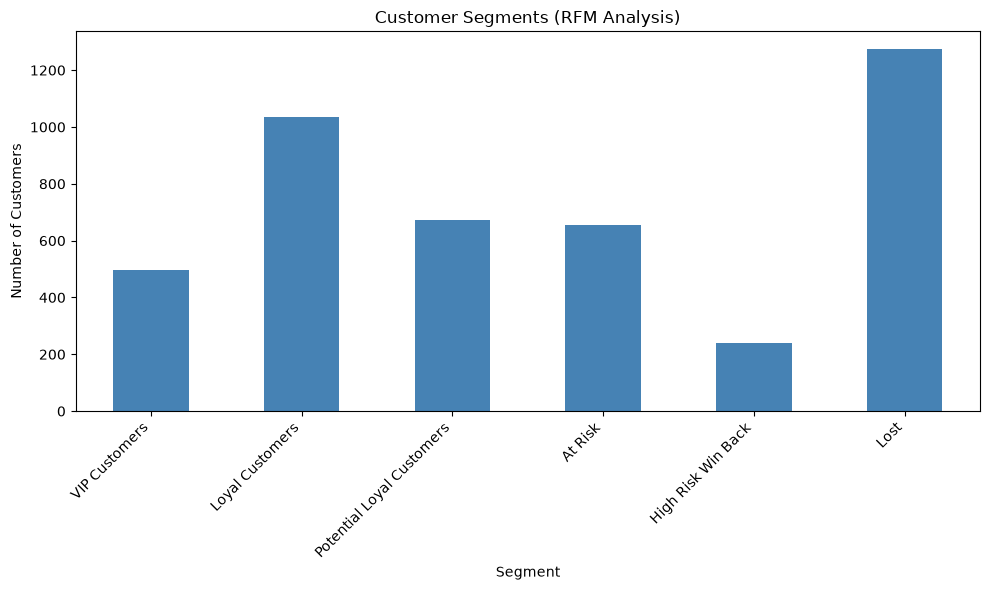

In [13]:
import matplotlib.pyplot as plt

segment_order = ['VIP Customers', 'Loyal Customers', 'Potential Loyal Customers', 
                  'At Risk', 'High Risk Win Back', 'Lost']

segment_counts = rfm_df['Segment'].value_counts().reindex(segment_order)

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color='steelblue')
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The segment distribution shows Lost (29%) and At Risk (15%) together make up nearly 
44% of the customer base - the largest area of concern. VIP Customers (11%) and 
High Risk Win Back (5%) are the smallest groups, but High Risk Win Back customers 
were historically high spenders, making them a high-priority target for retention 
despite their small size relative to Lost.

In [14]:
print(rfm_df['Recency'].describe())

count    4372.000000
mean       92.047118
std       100.765435
min         1.000000
25%        17.000000
50%        50.000000
75%       143.000000
max       374.000000
Name: Recency, dtype: float64


In [15]:
rfm_df['Churned'] = (rfm_df['Recency'] > 90).astype(int)
print(rfm_df['Churned'].value_counts())
print(rfm_df['Churned'].value_counts(normalize=True))

Churned
0    2918
1    1454
Name: count, dtype: int64
Churned
0    0.667429
1    0.332571
Name: proportion, dtype: float64


## Churn Prediction Modeling (Initial Attempt)

In [16]:
from sklearn.model_selection import train_test_split

x = rfm_df[['Frequency', 'Monetary']]
y = rfm_df['Churned']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)

(3497, 2) (875, 2)


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)

print("Model trained successfully")

Model trained successfully


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

y_predict = model.predict(x_test)
 
print("Accuracy:", accuracy_score(y_test, y_predict))
print("Precision:", precision_score(y_test, y_predict))
print("Recall:", recall_score(y_test, y_predict))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predict))
print("\nFull Report:")
print(classification_report(y_test, y_predict))

Accuracy: 0.7234285714285714
Precision: 0.5783132530120482
Recall: 0.5124555160142349

Confusion Matrix:
[[489 105]
 [137 144]]

Full Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       594
           1       0.58      0.51      0.54       281

    accuracy                           0.72       875
   macro avg       0.68      0.67      0.67       875
weighted avg       0.72      0.72      0.72       875



In [19]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 2324, 1: 1173}
After SMOTE: {1: 2324, 0: 2324}


In [21]:
model_smote = LogisticRegression()
model_smote.fit(x_train_smote, y_train_smote)

y_predict_smote = model_smote.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_predict_smote))
print("Precision:", precision_score(y_test, y_predict_smote))
print("Recall:", recall_score(y_test, y_predict_smote))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predict_smote))
print("\nFull Report:")
print(classification_report(y_test, y_predict_smote))                                                  

Accuracy: 0.6491428571428571
Precision: 0.4737903225806452
Recall: 0.8362989323843416

Confusion Matrix:
[[333 261]
 [ 46 235]]

Full Report:
              precision    recall  f1-score   support

           0       0.88      0.56      0.68       594
           1       0.47      0.84      0.60       281

    accuracy                           0.65       875
   macro avg       0.68      0.70      0.64       875
weighted avg       0.75      0.65      0.66       875



## Feature Engineering

In [22]:
# Get one row per customer per distinct invoice date (to avoid counting multiple line items as separate orders)
order_dates = df.groupby(['CustomerID', 'InvoiceNo'])['InvoiceDate'].first().reset_index()

# Sort by customer and date, then calculate the gap between consecutive orders
order_dates = order_dates.sort_values(['CustomerID', 'InvoiceDate'])
order_dates['days_since_last_order'] = order_dates.groupby('CustomerID')['InvoiceDate'].diff().dt.days

# Average gap per customer (customers with only 1 order will have NaN)
avg_gap = order_dates.groupby('CustomerID')['days_since_last_order'].mean().reset_index()
avg_gap.columns = ['CustomerID', 'Avg_Days_Between_Orders']

# Flag single-order customers before filling NaN, so the model can distinguish real averages from placeholders
avg_gap['Single_Order_Customer'] = avg_gap['Avg_Days_Between_Orders'].isna().astype(int)

median_gap = avg_gap['Avg_Days_Between_Orders'].median()
avg_gap['Avg_Days_Between_Orders'] = avg_gap['Avg_Days_Between_Orders'].fillna(median_gap)

print("Single-order customers:", avg_gap['Single_Order_Customer'].sum())
avg_gap.head(10)

Single-order customers: 1313


,CustomerID,Avg_Days_Between_Orders,Single_Order_Customer
0,12346.0,0.000000,0
1,12347.0,60.333333,0
2,12348.0,94.000000,0
3,12349.0,41.000000,1
4,12350.0,41.000000,1
5,12352.0,25.800000,0
6,12353.0,41.000000,1
7,12354.0,41.000000,1
8,12355.0,41.000000,1
9,12356.0,151.000000,0


Added average days between orders to capture purchase rhythm. ~30% of customers 
(1,313) have only one order, so there's no gap to calculate for them. Filled these 
with the overall median gap (41 days) as a neutral placeholder, and added a binary 
Single_Order_Customer flag so the model can distinguish real, customer-specific 
averages from this filled-in value.

In [23]:
rfm_df = rfm_df.merge(avg_gap, on='CustomerID', how='left')
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churned,Avg_Days_Between_Orders,Single_Order_Customer
0,12346.0,326,2,0.00,1,2,1,121,Lost,1,0.000000,0
1,12347.0,2,7,4310.00,4,4,4,444,VIP Customers,0,60.333333,0
2,12348.0,75,4,1797.24,2,3,4,234,At Risk,0,94.000000,0
3,12349.0,19,1,1757.55,3,1,4,314,Potential Loyal Customers,0,41.000000,1
4,12350.0,310,1,334.40,1,1,2,112,Lost,1,41.000000,1


In [24]:
# Count total orders and returned orders per customer
df['Is_Return'] = df['Quantity'] < 0

return_stats = df.groupby('CustomerID').agg(
    Total_Line_Items=('Quantity', 'count'),
    Returned_Line_Items=('Is_Return', 'sum')
).reset_index()

return_stats['Return_Rate'] = return_stats['Returned_Line_Items'] / return_stats['Total_Line_Items']

return_stats.head(10)

,CustomerID,Total_Line_Items,Returned_Line_Items,Return_Rate
0,12346.0,2,1,0.500000
1,12347.0,182,0,0.000000
2,12348.0,31,0,0.000000
3,12349.0,73,0,0.000000
4,12350.0,17,0,0.000000
5,12352.0,95,10,0.105263
6,12353.0,4,0,0.000000
7,12354.0,58,0,0.000000
8,12355.0,13,0,0.000000
9,12356.0,59,0,0.000000


In [25]:
rfm_df = rfm_df.merge(return_stats[['CustomerID', 'Return_Rate']], on='CustomerID', how='left')
print(rfm_df.shape)

rfm_df['Return_Rate'].describe()

(4372, 13)


count    4372.000000
mean        0.032053
std         0.106984
min         0.000000
25%         0.000000
50%         0.000000
75%         0.021048
max         1.000000
Name: Return_Rate, dtype: float64

Return_Rate distribution is heavily right-skewed: over half of customers have never 
returned an item (median = 0%), while a small subset show elevated return rates 
(max = 100%). This suggests return behavior could help flag a small group of customers with higher churn risk that Frequency and Monetary alone wouldn't catch.

In [26]:
# Get order-level total (not line-item level) per customer, in chronological order
order_totals = df.groupby(['CustomerID', 'InvoiceNo']).agg(
    Order_Date=('InvoiceDate', 'first'),
    Order_Value=('TotalPrice', 'sum')
).reset_index()

order_totals = order_totals.sort_values(['CustomerID', 'Order_Date'])

# For customers with 2+ orders, compare their first-half average order value to their second-half average
def spending_trend(group):
    if len(group) < 2:
        return pd.Series({'Spending_Trend': 0})  # not enough orders to measure a trend
    midpoint = len(group) // 2
    first_half_avg = group['Order_Value'].iloc[:midpoint].mean()
    second_half_avg = group['Order_Value'].iloc[midpoint:].mean()
    return pd.Series({'Spending_Trend': second_half_avg - first_half_avg})

trend_df = order_totals.groupby('CustomerID').apply(spending_trend, include_groups=False).reset_index()

trend_df.head(10)

,CustomerID,Spending_Trend
0,12346.0,-154367.200000
1,12347.0,13.832500
2,12348.0,-221.620000
3,12349.0,0.000000
4,12350.0,0.000000
5,12352.0,95.923333
6,12353.0,0.000000
7,12354.0,0.000000
8,12355.0,0.000000
9,12356.0,-2001.715000


In [27]:
order_totals[order_totals['CustomerID'] == 12346.0]

,CustomerID,InvoiceNo,Order_Date,Order_Value
0,12346.0,541431,2011-01-18 10:01:00,77183.6
1,12346.0,C541433,2011-01-18 10:17:00,-77183.6


Customer 12346 placed one large order ($77,183.60) and fully returned it 
16 minutes later, producing an extreme swing that reflects a single reversed 
transaction rather than a genuine spending trend. Capping Spending_Trend at the 
1st/99th percentiles to prevent this kind of outlier from distorting the feature 
for the rest of the customer base.

In [28]:
lower_cap = trend_df['Spending_Trend'].quantile(0.01)
upper_cap = trend_df['Spending_Trend'].quantile(0.99)

trend_df['Spending_Trend'] = trend_df['Spending_Trend'].clip(lower=lower_cap, upper=upper_cap)

print(f"Capped range: {lower_cap:.2f} to {upper_cap:.2f}")
trend_df['Spending_Trend'].describe()

Capped range: -1159.22 to 561.80


count    4372.000000
mean      -51.689860
std       231.532142
min     -1159.223023
25%       -91.613895
50%         0.000000
75%        18.275000
max       561.797487
Name: Spending_Trend, dtype: float64

In [29]:
rfm_df = rfm_df.merge(trend_df[['CustomerID', 'Spending_Trend']], on='CustomerID', how='left')
print(rfm_df.shape)
rfm_df.head()

(4372, 14)


,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churned,Avg_Days_Between_Orders,Single_Order_Customer,Return_Rate,Spending_Trend
0,12346.0,326,2,0.00,1,2,1,121,Lost,1,0.000000,0,0.5,-1159.223023
1,12347.0,2,7,4310.00,4,4,4,444,VIP Customers,0,60.333333,0,0.0,13.832500
2,12348.0,75,4,1797.24,2,3,4,234,At Risk,0,94.000000,0,0.0,-221.620000
3,12349.0,19,1,1757.55,3,1,4,314,Potential Loyal Customers,0,41.000000,1,0.0,0.000000
4,12350.0,310,1,334.40,1,1,2,112,Lost,1,41.000000,1,0.0,0.000000


In [30]:
feature_cols = ['Frequency', 'Monetary', 'Avg_Days_Between_Orders', 
                 'Single_Order_Customer', 'Return_Rate', 'Spending_Trend']

x = rfm_df[feature_cols]
y = rfm_df['Churned']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(x_train_smote.shape, x_test.shape)

(4648, 6) (875, 6)


## Churn Prediction Modeling (With Engineered Features)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_smote)
x_test_scaled = scaler.transform(x_test)

model_v2 = LogisticRegression(max_iter=1000)
model_v2.fit(x_train_scaled, y_train_smote)

y_pred_v2 = model_v2.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_v2))
print("Precision:", precision_score(y_test, y_pred_v2))
print("Recall:", recall_score(y_test, y_pred_v2))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))
print("\nFull Report:")
print(classification_report(y_test, y_pred_v2))

Accuracy: 0.7051428571428572
Precision: 0.5281173594132029
Recall: 0.7686832740213523

Confusion Matrix:
[[401 193]
 [ 65 216]]

Full Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       594
           1       0.53      0.77      0.63       281

    accuracy                           0.71       875
   macro avg       0.69      0.72      0.69       875
weighted avg       0.75      0.71      0.71       875



Adding behavioral features (avg. days between orders, return rate, spending trend) 
alongside SMOTE improved recall substantially over the baseline model (51% -> 77%) 
while partially recovering precision lost from SMOTE alone (47% -> 53%). This supports that 
these features carry real predictive signal beyond simple purchase count and spend.

## Feature Importance

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nFull Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6902857142857143
Precision: 0.5164473684210527
Recall: 0.5587188612099644

Confusion Matrix:
[[447 147]
 [124 157]]

Full Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       594
           1       0.52      0.56      0.54       281

    accuracy                           0.69       875
   macro avg       0.65      0.66      0.65       875
weighted avg       0.70      0.69      0.69       875



Random Forest underperforms, but here's its feature importance anyway:

In [33]:
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

importances

,Feature,Importance
1,Monetary,0.460156
2,Avg_Days_Between_Orders,0.158811
0,Frequency,0.157451
5,Spending_Trend,0.143408
4,Return_Rate,0.056830
3,Single_Order_Customer,0.023343


Feature importance from the Random Forest model shows Monetary value is by far the 
strongest predictor of churn (46% of total importance), followed by a cluster of 
behavioral features, each 
contributing comparably (14-16%). Return rate and single-order status contribute 
comparatively little, suggesting that how much and how consistently a customer 
spends matters more for predicting churn than whether they've ever returned an item.

## Churn Probability & Retention Priority

In [34]:
# Get churn probability for every customer in the test set
churn_probabilities = model_v2.predict_proba(x_test_scaled)[:, 1]

# Use the ORIGINAL unscaled feature values for display, not the scaled ones used for prediction
results_df = rfm_df.loc[x_test.index, ['CustomerID'] + feature_cols].copy()
results_df['Actual_Churned'] = y_test.values
results_df['Churn_Probability'] = churn_probabilities

results_df = results_df.sort_values('Churn_Probability', ascending=False).reset_index(drop=True)

results_df['Churn_Probability'] = results_df['Churn_Probability'].round(4)
results_df['Monetary'] = results_df['Monetary'].round(2)
results_df['Return_Rate'] = results_df['Return_Rate'].round(4)
results_df['Spending_Trend'] = results_df['Spending_Trend'].round(2)

results_df.head(15)

,CustomerID,Frequency,Monetary,Avg_Days_Between_Orders,Single_Order_Customer,Return_Rate,Spending_Trend,Actual_Churned,Churn_Probability
0,17307.0,1,-152.64,41.0,1,1.0000,0.00,1,0.9451
1,15638.0,1,-94.00,41.0,1,1.0000,0.00,1,0.9447
2,18256.0,1,-50.10,41.0,1,1.0000,0.00,1,0.9444
3,14679.0,1,-2.55,41.0,1,1.0000,0.00,1,0.9441
4,16995.0,1,-1.25,41.0,1,1.0000,0.00,1,0.9441
5,15823.0,2,-840.76,34.0,0,0.9412,-870.76,1,0.9311
6,18268.0,2,0.00,0.0,0,0.5000,51.00,1,0.8782
7,12558.0,2,0.00,5.0,0,0.5000,-539.92,0,0.8720
8,18133.0,2,715.50,1.0,0,0.5000,-1147.50,1,0.8634
9,16124.0,2,187.15,1.0,0,0.3125,-310.85,1,0.8291


In [35]:
results_df.tail()

,CustomerID,Frequency,Monetary,Avg_Days_Between_Orders,Single_Order_Customer,Return_Rate,Spending_Trend,Actual_Churned,Churn_Probability
870,14156.0,66,113214.59,5.169231,0,0.0141,-1159.22,0,0.0
871,17450.0,55,187322.17,6.333333,0,0.0400,561.80,0,0.0
872,13089.0,118,57322.13,2.760684,0,0.0210,103.89,0,0.0
873,17841.0,169,39869.05,1.827381,0,0.0174,92.40,0,0.0
874,12748.0,224,28405.56,1.336323,0,0.0103,45.59,0,0.0


The highest churn-probability customers share a distinct pattern: a single invoice that was itself a return (Frequency=1, negative Monetary, Return_Rate=1.0), meaning these customers never completed a net purchase within the observed data. This likely refers to returns of purchases made outside the dataset's date range, not a modeling error - flagging as a data limitation rather than a "high-risk active customer" pattern.

At the opposite extreme, the lowest-risk customers show consistently high Frequency (35+) and Monetary values ($5,000+), low return rates, and short average gaps between orders - the model correctly assigns these customers near-zero churn probability with high confidence, and all are correctly labeled as non-churned in the actual data. This symmetry of accuracy at both extremes suggests the model has learned a meaningful signal instead of just guessing near the middle.

In [36]:
priority_df = results_df.copy()

priority_df['Revenue_At_Risk'] = priority_df['Churn_Probability'] * priority_df['Monetary']

priority_df = priority_df.sort_values('Revenue_At_Risk', ascending=False)
priority_df.head(15)

,CustomerID,Frequency,Monetary,Avg_Days_Between_Orders,Single_Order_Customer,Return_Rate,Spending_Trend,Actual_Churned,Churn_Probability,Revenue_At_Risk
651,16000.0,3,12393.70,0.000000,0,0.0000,-1159.22,0,0.2603,3226.080110
375,18251.0,1,4314.72,41.000000,1,0.0000,0.00,0,0.5881,2537.486832
353,18087.0,4,3770.12,67.333333,0,0.7143,-1159.22,1,0.6203,2338.605436
362,15195.0,1,3861.00,41.000000,1,0.0000,0.00,0,0.6027,2327.024700
769,15749.0,4,21535.90,32.333333,0,0.3333,-1159.22,1,0.0905,1948.998950
412,14125.0,3,2720.63,33.500000,0,0.0000,-582.83,0,0.4934,1342.358842
579,12449.0,4,4067.29,54.333333,0,0.0000,396.76,0,0.3206,1303.973174
312,16986.0,2,1873.20,0.000000,0,0.0000,561.80,0,0.6878,1288.386960
659,12432.0,5,5059.32,32.000000,0,0.0000,-1077.44,0,0.2488,1258.758816
723,12435.0,2,7829.89,188.000000,0,0.0000,-128.09,0,0.1583,1239.471587


Ranking by Churn_Probability × Monetary tends to surface high-value customers with only moderate risk, not necessarily those most likely to churn. Filtering to a minimum probability threshold before ranking would give a more targeted retention list.

In [37]:
# Get churn probability for every customer in the test set
churn_probabilities = model_v2.predict_proba(x_test_scaled)[:, 1]

# Use the ORIGINAL unscaled feature values for display, not the scaled ones used for prediction
results_df = rfm_df.loc[x_test.index, ['CustomerID'] + feature_cols].copy()
results_df['Actual_Churned'] = y_test.values
results_df['Churn_Probability'] = churn_probabilities
results_df = results_df.sort_values('Churn_Probability', ascending=False).reset_index(drop=True)

# Add revenue at risk
priority_df = results_df.copy()
priority_df['Revenue_At_Risk'] = priority_df['Churn_Probability'] * priority_df['Monetary']
priority_df = priority_df.sort_values('Revenue_At_Risk', ascending=False)

# Filter to customers the model is genuinely confident will churn
high_risk_priority = priority_df[priority_df['Churn_Probability'] > 0.5].sort_values('Revenue_At_Risk', ascending=False)

print(high_risk_priority.shape)

(409, 10)


Final prioritized retention list (top candidates by expected revenue at risk):

In [38]:
priority_list = high_risk_priority[['CustomerID', 'Monetary', 'Churn_Probability', 'Revenue_At_Risk']].copy()
priority_list.head(15)

,CustomerID,Monetary,Churn_Probability,Revenue_At_Risk
375,18251.0,4314.72,0.588072,2537.365259
353,18087.0,3770.12,0.620298,2338.598826
362,15195.0,3861.00,0.602743,2327.191074
312,16986.0,1873.20,0.687819,1288.421721
332,14887.0,1862.00,0.664911,1238.063596
360,17679.0,1992.11,0.611930,1219.030999
327,15947.0,1708.24,0.669494,1143.656001
326,16902.0,1706.88,0.669534,1142.814440
358,12377.0,1628.12,0.613128,998.246235
405,16102.0,1842.14,0.504586,929.517516


## Key Findings & Conclusion

**Segmentation:** Customers were grouped into six segments (VIP, Loyal, Potential 
Loyal, At Risk, High Risk Win Back, Lost) based on RFM scoring. Nearly 44% of 
customers fall into the two lowest-engagement segments (At Risk and Lost), 
representing a significant retention opportunity.

**Churn likelihood:** A logistic regression model, trained on SMOTE-balanced data 
with engineered behavioral features, achieved 77% recall on churned customers, 
correctly identifying most at-risk customers while maintaining reasonable precision 
(53%). This outperformed both a baseline model without behavioral features (51% 
recall) and a Random Forest model with the same features (56% recall), showing 
that feature engineering contributed more to performance than model complexity alone.

**Key churn indicators:** Monetary value is the dominant predictor of churn (46% of 
feature importance), with purchase frequency, rhythm, and spending trend each 
contributing comparably as secondary signals. Return behavior played a minor role 
by comparison (see Feature Importance section for full breakdown).

**Retention priority:** Combining churn probability with customer value identified 
a concrete list of high-priority retention targets — customers who are both likely 
to churn and represent meaningful historical revenue. This list is directly 
actionable for a retention team.

**A note on model choice and retention cost:** the selected model favors recall 
over precision, meaning it will also flag some customers who wouldn't have actually 
churned. Whether this trade-off is worthwhile depends on the retention channel: 
for low-cost outreach (e.g., an automated email), having a wider net is reasonable; 
for high-cost outreach (e.g., personal account manager calls), a higher-precision 
model may be preferable to avoid wasting limited resources.

**Limitations & next steps:** This analysis was validated on a held-out test set 
(20% of customers). For actual deployment, the final model would be retrained on 
the full customer base so that every customer — not just the test-set subset — 
receives a churn probability and priority score. Additionally, this dataset spans 
only about one year, and return behavior for a small number of customers appears 
tied to purchases made outside the observed window, which should be considered a 
data limitation rather than a modeling error.